# Homework 4

**Coverage:** Lectures 13–15  
**Due:** Sunday, September 27, 2026, 11:59 p.m. ET  
**Total:** 100 points

## What this homework practices

| Lecture | Assessed ideas |
|:--|:--|
| 13 — Least squares | Derive a zero-intercept least-squares estimator and use validation to identify model failure. |
| 14 — Bayesian linear regression | Derive a Gaussian posterior and distinguish uncertainty about a latent curve from uncertainty about a future noisy observation. |
| 15 — Evidence, ARD, and diagnostics | Fit a linear-in-parameters nonlinear curve with automatic relevance determination, assess posterior-predictive calibration, and propagate coefficient uncertainty to ultimate strength. |

The repeated-sampling mean and variance in Problem 1, part 2, revisit
earlier probability material; the required calculation is scaffolded in
the problem.

Useful course-book pages are [Lecture 13: least
squares](https://predictivesciencelab.github.io/data-analytics-se/lecture13/reading-13.html),
[Lecture 14: Bayesian linear
regression](https://predictivesciencelab.github.io/data-analytics-se/lecture14/reading-14.html),
[Lecture 15: evidence approximation, ARD, and
diagnostics](https://predictivesciencelab.github.io/data-analytics-se/lecture15/reading-15.html),
and the [Lecture 15 ARD and diagnostic
example](https://predictivesciencelab.github.io/data-analytics-se/lecture15/hands-on-15.3.html).

The smoothly joined whole-curve model and posterior ultimate-strength
calculation are guided extensions. Every required definition and the
software-specific posterior-sampling helper are supplied below.

## Instructions

- Complete this notebook in Google Colab or another fresh Jupyter environment.
- Problem 1 is a hand-calculation problem. Show the important derivation and
  interpretation steps in Markdown/LaTeX, or insert one clearly legible image
  of your handwritten work. If you insert an image, accompany it with a
  descriptive alternative-text summary and type all final results. Code may
  check arithmetic only after the derivation is complete.
- Problem 2 is a scaffolded scientific-computing study. Use the supplied
  constants and seeds. Do not delete setup, helper, data-credit, or check cells.
- The setup cell downloads and verifies the frozen course data automatically.
  Do not upload a replacement file, mount Google Drive, or use an absolute
  data path. Saving your notebook copy in Drive is fine.
- Do not use the reserved assessment responses for quantitative fitting,
  model selection, or assessment before Section 2.3. You may show all rows
  in the initial descriptive plot. Do not install additional packages.
- Label every plot and state units. Strain is a dimensionless fraction;
  multiply it by 100 only when reporting percent strain. Report numerical
  answers to at least four significant digits unless instructed otherwise.
  The notebook records the installed scikit-learn version. Small
  version-dependent differences in the ARD active set and last reported
  digits are acceptable when the prescribed settings are unchanged.
- Follow the current course and Brightspace submission policies.

## Student details

- **First name:** Harishteja
- **Last name:** Peddi
- **Purdue email:** peddih@purdue.edu


In [1]:
from io import BytesIO
from pathlib import Path
import hashlib
import logging
import urllib.error
import urllib.request
import warnings

import numpy as np
import pandas as pd
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.polynomial.legendre import legval
from scipy import stats
from IPython import get_ipython
import sklearn
from sklearn.linear_model import ARDRegression
from sklearn.metrics import mean_squared_error

get_ipython().run_line_magic("matplotlib", "inline")
warnings.filterwarnings(
    "ignore", message="FigureCanvasAgg is non-interactive", category=UserWarning
)

SEED = 53904
sns.set_theme(style="ticks", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.constrained_layout.use"] = True
np.set_printoptions(precision=6, suppress=True)

DATA_NAME = "stress-strain-md.txt"
EXPECTED_DATA_SHA256 = (
    "dcd7e243a2cc47ea4695a283fd0c46433659f8cd18ddc6a5083b4ef5df71d062"
)
COURSE_DATA_URL = (
    "https://raw.githubusercontent.com/PredictiveScienceLab/data-analytics-se/"
    "066746a/lecturebook/data/stress_strain.txt"
)
LOCAL_DATA_CANDIDATES = (
    Path(DATA_NAME),
    Path("../data") / "stress_strain.txt",
    Path("lecturebook/data") / "stress_strain.txt",
)


def sha256_bytes(payload):
    '''Return the hexadecimal SHA-256 digest of a byte string.'''
    return hashlib.sha256(payload).hexdigest()


def load_frozen_course_data():
    '''Load the hash-verified course file locally or from the pinned URL.'''
    rejected = []
    for candidate in LOCAL_DATA_CANDIDATES:
        if candidate.is_file():
            payload = candidate.read_bytes()
            digest = sha256_bytes(payload)
            if digest == EXPECTED_DATA_SHA256:
                return payload, f"verified local course file: {candidate}"
            rejected.append(f"{candidate} (SHA-256 {digest})")

    request = urllib.request.Request(
        COURSE_DATA_URL,
        headers={"User-Agent": "ME539-course-data/2026"},
    )
    try:
        with urllib.request.urlopen(request, timeout=30) as response:
            payload = response.read()
    except (urllib.error.URLError, TimeoutError) as exc:
        rejected_text = (
            f" Rejected local files: {', '.join(rejected)}."
            if rejected
            else ""
        )
        raise RuntimeError(
            "Could not download the frozen Homework 4 course data. "
            "Check the internet connection and rerun this cell."
            + rejected_text
        ) from exc

    digest = sha256_bytes(payload)
    if digest != EXPECTED_DATA_SHA256:
        raise ValueError(
            "Downloaded bytes do not match the frozen course data: "
            f"expected {EXPECTED_DATA_SHA256}, received {digest}."
        )
    return payload, f"verified course-repository file: {COURSE_DATA_URL}"


DATA_BYTES, DATA_SOURCE = load_frozen_course_data()
data = pd.read_csv(BytesIO(DATA_BYTES), sep=r"\s+")
data = data.rename(columns={"#ex": "strain", "Sx": "stress_mpa"})
data = data[["strain", "stress_mpa"]].astype(float)

assert data.shape == (1001, 2)
assert np.isfinite(data.to_numpy()).all()
assert np.all(np.diff(data["strain"]) > 0)

strain = data["strain"].to_numpy()
stress_mpa = data["stress_mpa"].to_numpy()
row_number = np.arange(len(data))
ASSESSMENT_MASK = row_number % 5 == 0
DEVELOPMENT_MASK = ~ASSESSMENT_MASK

ELASTIC_NOISE_SD = 30.0       # MPa; working scale for the elastic study
ELASTIC_PRIOR_MEAN = 7000.0   # MPa
ELASTIC_PRIOR_SD = 3000.0     # MPa
CANDIDATE_CUTOFFS = np.round(np.arange(0.010, 0.0601, 0.005), 3)

ARD_MAX_LEGENDRE_ORDER = 14
ARD_THRESHOLD = 10000.0
N_POSTERIOR_DRAWS = 4000

print(f"Loaded {len(DATA_BYTES)} verified bytes from {DATA_SOURCE}.")
print(
    f"Rows: {len(data)}; development: {DEVELOPMENT_MASK.sum()}; "
    f"assessment: {ASSESSMENT_MASK.sum()}; scikit-learn: {sklearn.__version__}"
)
data.head()


Loaded 35224 verified bytes from verified course-repository file: https://raw.githubusercontent.com/PredictiveScienceLab/data-analytics-se/066746a/lecturebook/data/stress_strain.txt.
Rows: 1001; development: 800; assessment: 201; scikit-learn: 1.6.1


,strain,stress_mpa
0,0.000000,-29.489760
1,0.000252,11.779628
2,0.000503,45.195298
3,0.000755,49.495215
4,0.001007,42.283019


## Data and problem credit

The stress–strain values come from a molecular-dynamics tensile-loading
simulation shared for course use by [Professor Alejandro Strachan's
group](https://engineering.purdue.edu/MSE/people/ptProfile?id=33239).
Strain is dimensionless and stress is reported in MPa. The distributed
file does not identify the material composition or record the simulation
settings, so this homework makes no claim about either one.

Both problems were written for ME 539 around this physical setting and the
regression methods in Lectures 13–15. The smooth-basis construction below
is supplied as part of the problem; the ARD implementation is
[scikit-learn's
`ARDRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ARDRegression.html).


## Problem 1 — Zero-intercept elastic regression (25 points)

Consider fixed strains $\epsilon_1,\ldots,\epsilon_n$ and the model

$$

\sigma_i=E\epsilon_i+e_i,
\qquad
e_i\overset{\mathrm{iid}}{\sim}\mathcal{N}(0,s^2),

$$

where stress $\sigma_i$, Young's modulus $E$, and $e_i$ are measured in
MPa, while strain $\epsilon_i$ is dimensionless. Assume $s^2$ is known and
$\sum_{i=1}^{n}\epsilon_i^2>0$. Before observing the stresses, use

$$

E\sim\mathcal{N}(m_0,s_0^2).

$$

1. **Least-squares estimator (5 points).** Minimize the sum of squared
   residuals and derive the least-squares estimator $\widehat E$.
2. **Repeated-sampling properties (6 points).** An estimator is **unbiased**
   if its expected value equals the true parameter. The expectation is over
   repeated datasets generated with that parameter held fixed. Substitute
   the observation model into your least-squares estimator $\widehat E$.
   Keeping the strains and true Young's modulus $E$ fixed, show that the
   estimator's expected value equals $E$, and derive its sampling variance.
   Here, *sampling variance* means variance over repeated draws of the
   observation errors while the strains and true $E$ stay fixed.
3. **Gaussian posterior (8 points).** Complete the square to derive the
   posterior distribution of $E$. State its mean $m_N$ and variance
   $s_N^2$.
4. **Connections, limits, and units (6 points).** Rewrite $m_N$ as a
   precision-weighted combination of $m_0$ and $\widehat E$. Show that the
   diffuse-prior limit, $s_0^2\to\infty$, reproduces both the least-squares
   estimate and its sampling variance. Holding the observed data fixed,
   describe the posterior limit as $s^2\to0$. State the units of every mean,
   standard deviation, and variance in your result, and explain why
   $\sum_i\epsilon_i^2>0$ is required.

> **Problem credit.** This course-authored problem applies the least-squares
> and Gaussian-regression formulas developed in Lectures 13–14 to the
> zero-intercept form of Hooke's law.



### Part 1 - Least-squares estimator

We model $\sigma_i = E\epsilon_i + e_i$ and want the value of $E$ that best fits the data in the least-squares sense — i.e., the $E$ that minimizes the total squared mismatch between observed stress and predicted stress $E\epsilon_i$.

Define the objective (sum of squared residuals):
$$
J(E) = \sum_{i=1}^n (\sigma_i - E\epsilon_i)^2
$$

Differentiate with respect to $E$ and set equal to zero (first-order optimality condition):
$$
\frac{dJ}{dE} = \sum_{i=1}^n 2(\sigma_i - E\epsilon_i)(-\epsilon_i) = -2\sum_{i=1}^n \epsilon_i(\sigma_i - E\epsilon_i)
$$

Setting $\frac{dJ}{dE} = 0$:
$$
\sum_{i=1}^n \epsilon_i(\sigma_i - E\epsilon_i) = 0
\;\Longrightarrow\;
\sum_{i=1}^n \epsilon_i\sigma_i - E\sum_{i=1}^n \epsilon_i^2 = 0
\;\Longrightarrow\;
\sum_{i=1}^n \epsilon_i\sigma_i = E\sum_{i=1}^n \epsilon_i^2
$$

Solving for $E$ (dividing both sides by $\sum_i \epsilon_i^2$, which is strictly positive by assumption):

$$
\hat E = \frac{\displaystyle\sum_{i=1}^n \epsilon_i \sigma_i}{\displaystyle\sum_{i=1}^n \epsilon_i^2}
$$

**Confirming it's a minimum, not a maximum or saddle:** the second derivative is
$$
\frac{d^2J}{dE^2} = 2\sum_{i=1}^n \epsilon_i^2 > 0
$$
which is strictly positive whenever at least one $\epsilon_i \neq 0$. A positive second derivative means $J(E)$ is convex, so the stationary point $\hat E$ is indeed the unique global minimum.


### Part 2 - Repeated-sampling properties (bias and variance)

"Repeated sampling" means: imagine the strains $\epsilon_1,\dots,\epsilon_n$ and the true modulus $E$ are fixed and known, but the noise $e_1,\dots,e_n$ is redrawn independently from $\mathcal N(0, s^2)$ every time we run a new experiment. Each run produces new stresses $\sigma_i$ and hence a new estimate $\hat E$. We want the mean and variance of $\hat E$ across these hypothetical repeated experiments.

**Step 1: substitute the true model into $\hat E$.**

$$
\hat E = \frac{\sum_i \epsilon_i \sigma_i}{\sum_i \epsilon_i^2}
= \frac{\sum_i \epsilon_i(E\epsilon_i + e_i)}{\sum_i \epsilon_i^2}
= \frac{E\sum_i \epsilon_i^2 + \sum_i \epsilon_i e_i}{\sum_i \epsilon_i^2}
$$

Split the fraction into two terms:
$$
\hat E = \frac{E\sum_i \epsilon_i^2}{\sum_i \epsilon_i^2} + \frac{\sum_i \epsilon_i e_i}{\sum_i \epsilon_i^2}
= E + \frac{\sum_i \epsilon_i e_i}{\sum_i \epsilon_i^2}
$$

This is the key identity: the estimator equals the truth $E$ plus a noise term that is a weighted sum of the $e_i$.

**Step 2: take the expectation.**

Since $\epsilon_i$ are fixed constants and $\mathbb E[e_i] = 0$ for every $i$:
$$
\mathbb E[\hat E] = E + \frac{\sum_i \epsilon_i\,\mathbb E[e_i]}{\sum_i \epsilon_i^2} = E + \frac{\sum_i \epsilon_i \cdot 0}{\sum_i \epsilon_i^2} = E
$$

So $\mathbb E[\hat E] = E$ for any true value of $E$ — the estimator is **unbiased**: on average, across repeated experiments, it recovers the true modulus.

**Step 3: compute the variance.**

Since $E$ is a constant, it contributes nothing to the variance:
$$
\operatorname{Var}(\hat E) = \operatorname{Var}\!\left(\frac{\sum_i \epsilon_i e_i}{\sum_i \epsilon_i^2}\right)
$$

The denominator $\sum_i \epsilon_i^2$ is a constant (not random), so it can be pulled out of the variance as its square:
$$
\operatorname{Var}(\hat E) = \frac{1}{\left(\sum_i \epsilon_i^2\right)^2}\operatorname{Var}\!\left(\sum_i \epsilon_i e_i\right)
$$

Because the $e_i$ are independent, the variance of their (weighted) sum is the sum of the variances of each term:
$$
\operatorname{Var}\!\left(\sum_i \epsilon_i e_i\right) = \sum_i \epsilon_i^2 \operatorname{Var}(e_i) = \sum_i \epsilon_i^2 \cdot s^2 = s^2\sum_i \epsilon_i^2
$$

Substituting back:
$$
\operatorname{Var}(\hat E) = \frac{s^2\sum_i \epsilon_i^2}{\left(\sum_i \epsilon_i^2\right)^2} = \frac{s^2}{\sum_{i=1}^n \epsilon_i^2}
$$

**Interpretation:** the more spread-out and numerous the strain measurements (larger $\sum_i \epsilon_i^2$), the smaller the sampling variance of $\hat E$ — more informative data pin down $E$ more tightly.



### Part 3 — Gaussian posterior

**Setting up the prior density.** We're told $E \sim \mathcal N(m_0, s_0^2)$, so its probability density function is
$$
p(E) = \frac{1}{\sqrt{2\pi s_0^2}}\exp\!\left(-\frac{(E-m_0)^2}{2s_0^2}\right)
$$
The normalizing prefactor does not depend on $E$, so for the purpose of finding the posterior's shape in $E$ we can drop it:
$$
p(E) \propto \exp\!\left(-\frac{(E-m_0)^2}{2s_0^2}\right)
$$

**Setting up the likelihood.** Given $E$, each observation satisfies $\sigma_i = E\epsilon_i + e_i$ with $e_i \sim \mathcal N(0,s^2)$, so $\sigma_i \mid E \sim \mathcal N(E\epsilon_i, s^2)$:
$$
p(\sigma_i \mid E) = \frac{1}{\sqrt{2\pi s^2}}\exp\!\left(-\frac{(\sigma_i - E\epsilon_i)^2}{2s^2}\right)
$$
Since the noise terms are independent, the joint likelihood of all $n$ observations is the product of the individual densities. Multiplying exponentials adds their exponents:
$$
p(\boldsymbol\sigma\mid E) = \prod_{i=1}^n p(\sigma_i \mid E) \propto \exp\!\left(-\frac{1}{2s^2}\sum_{i=1}^n(\sigma_i - E\epsilon_i)^2\right)
$$

**Combining via Bayes' rule.** The posterior is proportional to prior times likelihood:
$$
p(E \mid \boldsymbol\sigma) \propto \exp\!\left[-\frac{1}{2}\left(\frac{(E-m_0)^2}{s_0^2} + \frac{1}{s^2}\sum_i(\sigma_i-E\epsilon_i)^2\right)\right]
$$

Call the bracketed quantity $Q(E)$. We now expand it and collect powers of $E$.

**Expanding $Q(E)$:**
$$
Q(E) = \frac{E^2 - 2Em_0 + m_0^2}{s_0^2} + \frac{1}{s^2}\sum_i\left(\sigma_i^2 - 2E\epsilon_i\sigma_i + E^2\epsilon_i^2\right)
$$

$$
= \frac{E^2}{s_0^2} - \frac{2Em_0}{s_0^2} + \frac{m_0^2}{s_0^2}
+ \frac{E^2\sum_i\epsilon_i^2}{s^2} - \frac{2E\sum_i\epsilon_i\sigma_i}{s^2} + \frac{\sum_i\sigma_i^2}{s^2}
$$

Group by powers of $E$:
$$
Q(E) = \underbrace{\left(\frac{1}{s_0^2}+\frac{\sum_i\epsilon_i^2}{s^2}\right)}_{A}E^2
\;-\; 2\underbrace{\left(\frac{m_0}{s_0^2}+\frac{\sum_i\epsilon_i\sigma_i}{s^2}\right)}_{B}E
\;+\; (\text{terms with no } E)
$$

**Completing the square.** Any expression $AE^2 - 2BE + C$ can be rewritten as $A(E - B/A)^2 + \text{const}$. Matching this to the target form $\dfrac{(E-m_N)^2}{s_N^2} = \dfrac{1}{s_N^2}E^2 - \dfrac{2m_N}{s_N^2}E + \text{const}$, we identify:

$$
\frac{1}{s_N^2} = A = \frac{1}{s_0^2}+\frac{\sum_i\epsilon_i^2}{s^2}
\qquad\text{and}\qquad
\frac{m_N}{s_N^2} = B = \frac{m_0}{s_0^2}+\frac{\sum_i\epsilon_i\sigma_i}{s^2}
$$

Solving the second equation for $m_N$ (multiply both sides by $s_N^2$):

$$
m_N = s_N^2\left(\frac{m_0}{s_0^2} + \frac{\sum_i \epsilon_i\sigma_i}{s^2}\right)
$$

So the posterior is Gaussian, $E \mid \boldsymbol\sigma \sim \mathcal N(m_N, s_N^2)$, with

$$
\boxed{\frac{1}{s_N^2} = \frac{1}{s_0^2} + \frac{\sum_i \epsilon_i^2}{s^2}}
\qquad\qquad
\boxed{m_N = s_N^2\left(\frac{m_0}{s_0^2} + \frac{\sum_i \epsilon_i\sigma_i}{s^2}\right)}
$$


### Part 4 — Connections, limits, and units

**Rewriting $m_N$ as a precision-weighted average.**

Recall from Part 1 that $\hat E = \dfrac{\sum_i\epsilon_i\sigma_i}{\sum_i\epsilon_i^2}$, which rearranges to $\sum_i\epsilon_i\sigma_i = \hat E\sum_i\epsilon_i^2$. Substitute this into the numerator of $m_N$'s defining equation:

$$
m_N = s_N^2\left(\frac{m_0}{s_0^2} + \frac{\hat E\sum_i\epsilon_i^2}{s^2}\right)
$$

and recall $s_N^2 = 1\big/\left(\dfrac{1}{s_0^2}+\dfrac{\sum_i\epsilon_i^2}{s^2}\right)$. Writing this out explicitly as a ratio:

$$
m_N = \frac{\dfrac{m_0}{s_0^2} + \hat E\cdot\dfrac{\sum_i\epsilon_i^2}{s^2}}{\dfrac{1}{s_0^2} + \dfrac{\sum_i\epsilon_i^2}{s^2}}
$$

This is precisely a **weighted average of $m_0$ and $\hat E$**, where the weight on each is its *precision* (inverse variance): the prior contributes weight $1/s_0^2$, and the data contributes weight $\sum_i\epsilon_i^2/s^2$. Notice from Part 2 that $\sum_i\epsilon_i^2/s^2 = 1/\operatorname{Var}(\hat E)$ — so the data's weight is exactly its own sampling precision. Whichever source (prior or data) is more precise (smaller variance) pulls $m_N$ more strongly toward its own value.

**Limit 1: diffuse prior, $s_0^2 \to \infty$.**

As $s_0^2 \to \infty$, the prior precision $1/s_0^2 \to 0$. Then:
$$
\frac{1}{s_N^2} \to 0 + \frac{\sum_i\epsilon_i^2}{s^2} = \frac{\sum_i\epsilon_i^2}{s^2}
\quad\Longrightarrow\quad
s_N^2 \to \frac{s^2}{\sum_i\epsilon_i^2}
$$
which is exactly $\operatorname{Var}(\hat E)$ from Part 2. Likewise, the $m_0/s_0^2$ term in $m_N$'s numerator vanishes, leaving
$$
m_N \to \hat E
$$
So an infinitely vague prior means the posterior mean and variance reduce exactly to the least-squares point estimate and its sampling variance — the Bayesian answer collapses onto the frequentist one when the prior carries no information.

**Limit 2: perfect data, $s^2 \to 0$ (strains and observed stresses held fixed).**

As $s^2 \to 0$, the data precision $\sum_i\epsilon_i^2/s^2 \to \infty$. Then $1/s_N^2 \to \infty$, so $s_N^2 \to 0$: the posterior becomes a spike (essentially certain). And since the data term dominates the weighted average overwhelmingly, $m_N \to \hat E$ as well. With noiseless measurements, the data completely determines $E$ and the prior becomes irrelevant, regardless of how informative or vague it was.

**Units.**

- Strain $\epsilon_i$ is dimensionless; stress $\sigma_i$ is in MPa.
- From $\sigma_i = E\epsilon_i + e_i$, since $\sigma_i$ is MPa and $\epsilon_i$ is dimensionless, $E$ must be in **MPa** (and so must the noise term $e_i$, for the equation to be dimensionally consistent).
- Therefore $\hat E$, $m_0$, and $m_N$ — all being point values or means of $E$ — are in **MPa**.
- $s$, $s_0$, and $s_N$ are standard deviations of quantities measured in MPa, so they are also in **MPa**.
- $s^2$, $s_0^2$, and $s_N^2$, being variances, are in **MPa²**.

**Why $\sum_i \epsilon_i^2 > 0$ is required.**

If every $\epsilon_i = 0$ (or, degenerately, if $n=0$), then $\sum_i\epsilon_i^2 = 0$ and several things break simultaneously:
- $\hat E = \dfrac{\sum_i\epsilon_i\sigma_i}{\sum_i\epsilon_i^2} = \dfrac{0}{0}$ is undefined — the least-squares problem has no unique solution because $J(E) = \sum_i\sigma_i^2$ doesn't depend on $E$ at all (every value of $E$ fits equally, or equally badly).
- $\operatorname{Var}(\hat E) = s^2/\sum_i\epsilon_i^2 \to \infty$ — with no strain variation, the data are completely uninformative about $E$.
- In the posterior, the data-precision term $\sum_i\epsilon_i^2/s^2$ vanishes, leaving $s_N^2 = s_0^2$ and $m_N = m_0$: the posterior is identical to the prior, meaning the data taught us nothing about $E$.

The condition $\sum_i\epsilon_i^2 > 0$ is exactly what's needed for the strains to vary enough that stress actually carries information about the slope $E$ — i.e., for $E$ to be **identifiable** from the data.

## Problem 2 — From elastic modulus to ultimate strength (75 points)

The first part of the loading curve may follow Hooke's law, but the
material then hardens, reaches a peak stress, and softens. In this problem,
the **latent stress–strain curve** $f(\epsilon)$ is the underlying curve
before observation noise is added. Define the **ultimate strength over the
observed loading range** as

$$

U=\max_{0\leq\epsilon\leq\epsilon_{\max}}f(\epsilon),

$$

where $\epsilon_{\max}$ is the largest observed strain. This is not the
largest noisy stress in the data.

Every fifth row has been reserved as an assessment subset. You may show all
observations in the initial descriptive plot, but use only
`DEVELOPMENT_MASK` for quantitative fitting and model selection through
Section 2.2. The assessment responses first enter a quantitative
calculation in Section 2.3.

> **Problem credit.** This course-authored study uses the credited
> molecular-dynamics data and the evidence-approximation, ARD, and
> diagnostic methods taught in Lecture 15.


### 2.1 Select a defensible elastic range (20 points)

1. Plot stress against percent strain. Describe the initial elastic-looking,
   nonlinear/hardening, peak, and softening regimes. **(3 points)**
2. Implement the least-squares and Gaussian-posterior formulas from Problem
   1. For each supplied cutoff, fit all development observations at or
   below the cutoff and check the next five development observations. A
   cutoff passes only when at least four of those five stresses lie in
   their 95% posterior-predictive intervals and the absolute mean signed
   residual is at most `ELASTIC_NOISE_SD`. Tabulate both criteria, plot them
   against cutoff, and select the largest passing cutoff. Store it in the
   variable `selected_cutoff`, which later supplied cells use.
   **(9 points)**
3. Refit at the selected cutoff. Report it as a strain fraction and percent,
   and report $E$'s posterior mean and central 95% credible interval in GPa.
   At strain $0.02$, report and mark on your plot the 95% interval for the latent stress
   $E\epsilon$ and the 95% posterior-predictive interval for a future noisy
   stress. Explain why the latter is wider. **(8 points)**

In this section, use the supplied working noise scale and prior. Later, ARD
will estimate a separate noise level for the whole-curve model. The
selected value is an **operational elastic cutoff under this prescribed
rule**; do not interpret it as an independently established yield strain or
material constant.


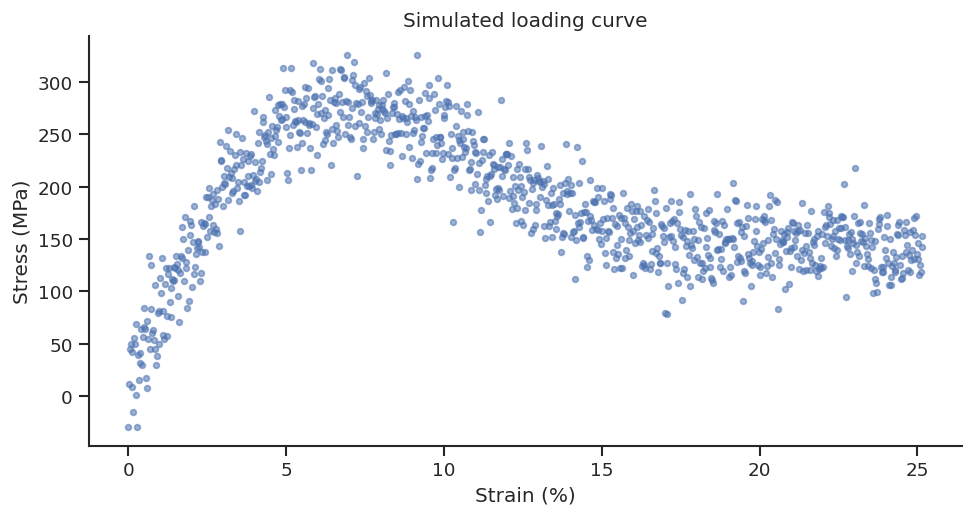

,cutoff,fit_rows,covered_of_5,mean_signed_residual_mpa,passes
0,0.010,32,5,-1.0193,True
1,0.015,48,4,-20.4831,True
2,0.020,64,5,-19.0415,True
3,0.025,80,5,-11.0694,True
4,0.030,96,5,10.2983,True
5,0.035,112,5,-20.1184,True
6,0.040,127,3,-52.5622,False
7,0.045,143,5,-33.3070,False
8,0.050,159,3,-53.7986,False
9,0.055,175,5,-39.3773,False


Selected cutoff: 0.035 (3.50%)
Elastic LS estimate: 6.769849 GPa
Elastic posterior mean: 6.770344 GPa
Elastic 95% credible interval: [6.497406, 7.043283] GPa
At strain 0.02, posterior mean stress: 135.4069 MPa
Latent 95% interval: [129.9481 140.8657] MPa
Posterior-predictive 95% interval: [ 76.3551 194.4587] MPa


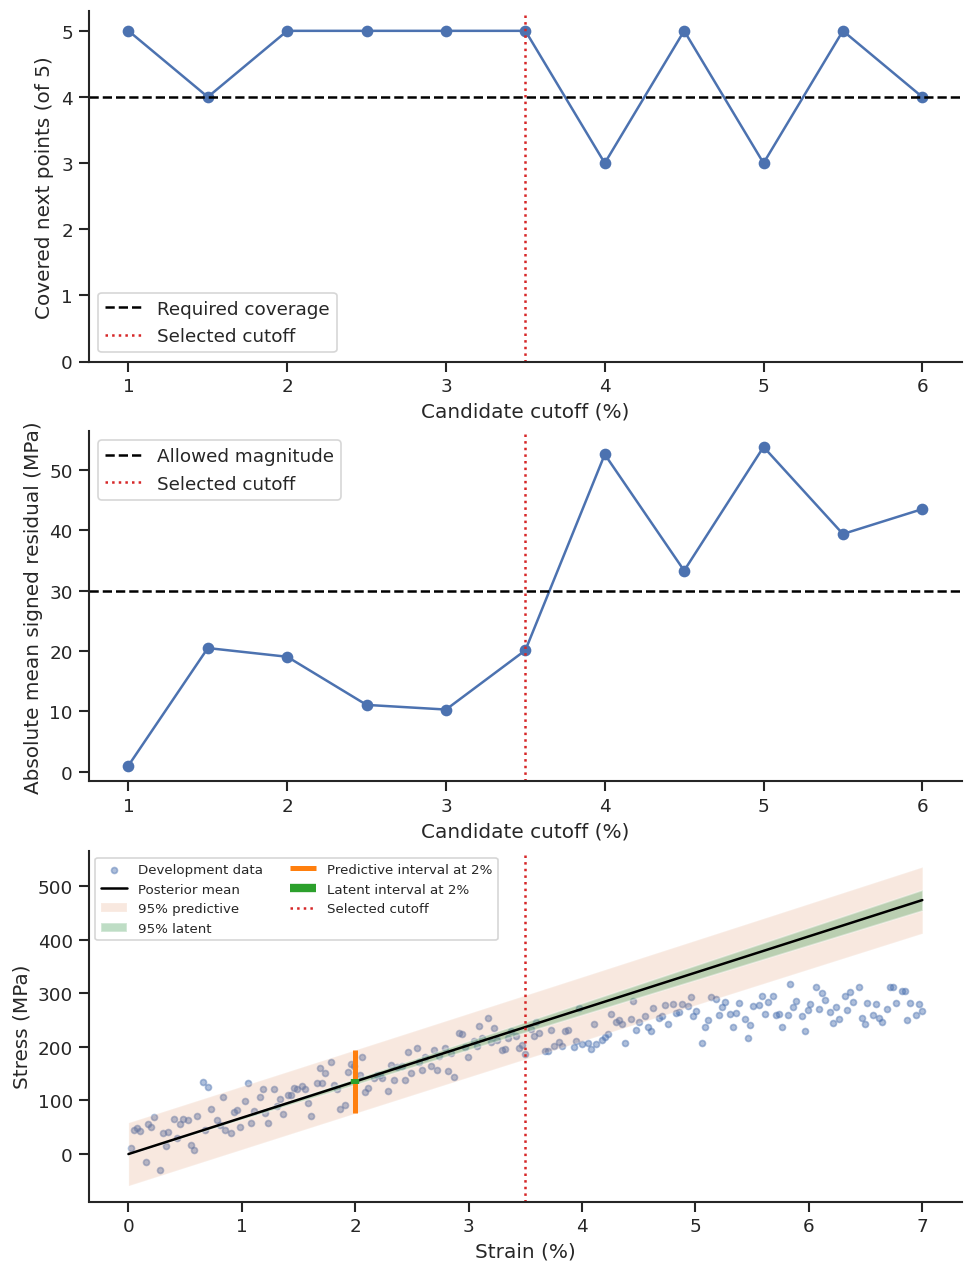

In [2]:
def fit_zero_intercept_bayes(
    epsilon,
    sigma,
    noise_sd=ELASTIC_NOISE_SD,
    prior_mean=ELASTIC_PRIOR_MEAN,
    prior_sd=ELASTIC_PRIOR_SD,
):
    '''Return the LS estimate and Gaussian posterior mean and variance.'''
    epsilon = np.asarray(epsilon, dtype=float)
    sigma = np.asarray(sigma, dtype=float)

    # TODO: replace the five None values using your Problem 1 formulas.
    sum_epsilon_sq = np.sum(epsilon ** 2)
    sum_epsilon_sigma = np.sum(epsilon * sigma)
    ls_estimate = sum_epsilon_sigma / sum_epsilon_sq
    posterior_variance = 1.0 / ( 1.0 / prior_sd ** 2 + sum_epsilon_sq / noise_sd ** 2)
    posterior_mean = posterior_variance * (prior_mean / prior_sd ** 2 + sum_epsilon_sigma / noise_sd ** 2)

    if any(
        value is None
        for value in (
            sum_epsilon_sq,
            sum_epsilon_sigma,
            ls_estimate,
            posterior_variance,
            posterior_mean,
        )
    ):
        raise NotImplementedError("Complete fit_zero_intercept_bayes.")
    if sum_epsilon_sq <= 0:
        raise ValueError("At least one strain must be nonzero.")
    return {
        "ls_estimate": ls_estimate,
        "posterior_mean": posterior_mean,
        "posterior_variance": posterior_variance,
    }


def elastic_predictive_summary(epsilon_new, fit, noise_sd=ELASTIC_NOISE_SD):
    '''Return latent mean, epistemic SD, and posterior-predictive SD.'''
    epsilon_new = np.asarray(epsilon_new, dtype=float)

    # TODO: replace the three None values using the definitions above.
    latent_mean = fit["posterior_mean"] * epsilon_new
    epistemic_sd = np.sqrt(fit["posterior_variance"]) * np.abs(epsilon_new)
    predictive_sd = np.sqrt(fit["posterior_variance"] * epsilon_new ** 2 + noise_sd ** 2)

    if any(value is None for value in (latent_mean, epistemic_sd, predictive_sd)):
        raise NotImplementedError("Complete elastic_predictive_summary.")
    return latent_mean, epistemic_sd, predictive_sd


# Use only the development observations for cutoff selection.
development_strain = strain[DEVELOPMENT_MASK]
development_stress = stress_mpa[DEVELOPMENT_MASK]

# Plotting and table boilerplate is supplied. Fill only the marked lines.
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.scatter(100 * strain, stress_mpa, s=12, alpha=0.55)
ax.set(xlabel="Strain (%)", ylabel="Stress (MPa)", title="Simulated loading curve")
sns.despine(ax=ax)
plt.show()

cutoff_rows = []
normal_975 = stats.norm.ppf(0.975)
for cutoff in CANDIDATE_CUTOFFS:
    fit_mask = development_strain <= cutoff
    validation_positions = np.flatnonzero(development_strain > cutoff)[:5]
    if len(validation_positions) != 5:
        raise ValueError(f"Cutoff {cutoff} does not have five following points.")
    fit = fit_zero_intercept_bayes(
        development_strain[fit_mask], development_stress[fit_mask]
    )
    validation_epsilon = development_strain[validation_positions]
    validation_stress = development_stress[validation_positions]
    mean, _, predictive_sd = elastic_predictive_summary(validation_epsilon, fit)

    # Supplied metric bookkeeping. You will interpret both checks and use
    # the table to select the largest passing cutoff.
    residual = validation_stress - mean
    covered = np.abs(residual) <= normal_975 * predictive_sd
    mean_signed_residual = residual.mean()
    passes = (
        covered.sum() >= 4
        and abs(mean_signed_residual) <= ELASTIC_NOISE_SD
    )
    cutoff_rows.append(
        {
            "cutoff": cutoff,
            "fit_rows": int(fit_mask.sum()),
            "covered_of_5": int(covered.sum()),
            "mean_signed_residual_mpa": mean_signed_residual,
            "passes": passes,
        }
    )

cutoff_table = pd.DataFrame(cutoff_rows)

# TODO: replace None with the largest cutoff whose `passes` value is True.
selected_cutoff = cutoff_table.loc[cutoff_table["passes"], "cutoff"].max()
if selected_cutoff is None:
    raise NotImplementedError("Assign selected_cutoff.")

# The remaining numerical summaries and plotting boilerplate are supplied.
selected_mask = development_strain <= selected_cutoff
elastic_fit = fit_zero_intercept_bayes(
    development_strain[selected_mask], development_stress[selected_mask]
)
elastic_sd = np.sqrt(elastic_fit["posterior_variance"])
elastic_ci_mpa = (
    elastic_fit["posterior_mean"]
    + np.array([-1, 1]) * normal_975 * elastic_sd
)
epsilon_query = np.array([0.02])
query_mean, query_epistemic_sd, query_predictive_sd = elastic_predictive_summary(
    epsilon_query, elastic_fit
)
query_latent_ci = (
    query_mean[0]
    + np.array([-1, 1]) * normal_975 * query_epistemic_sd[0]
)
query_predictive_ci = (
    query_mean[0]
    + np.array([-1, 1]) * normal_975 * query_predictive_sd[0]
)

display(cutoff_table.round(4))
print(f"Selected cutoff: {selected_cutoff:.3f} ({100 * selected_cutoff:.2f}%)")
print(f"Elastic LS estimate: {elastic_fit['ls_estimate'] / 1000:.6f} GPa")
print(f"Elastic posterior mean: {elastic_fit['posterior_mean'] / 1000:.6f} GPa")
print(
    "Elastic 95% credible interval: "
    f"[{elastic_ci_mpa[0] / 1000:.6f}, {elastic_ci_mpa[1] / 1000:.6f}] GPa"
)
print(f"At strain 0.02, posterior mean stress: {query_mean[0]:.4f} MPa")
print(f"Latent 95% interval: {query_latent_ci.round(4)} MPa")
print(f"Posterior-predictive 95% interval: {query_predictive_ci.round(4)} MPa")

fig, axes = plt.subplots(3, 1, figsize=(8, 10.5))
axes[0].plot(cutoff_table["cutoff"] * 100, cutoff_table["covered_of_5"], "o-")
axes[0].axhline(4, color="black", linestyle="--", label="Required coverage")
axes[0].axvline(
    100 * selected_cutoff, color="tab:red", linestyle=":", label="Selected cutoff"
)
axes[0].set(xlabel="Candidate cutoff (%)", ylabel="Covered next points (of 5)")
axes[0].set_ylim(0, 5.3)
axes[0].legend()

axes[1].plot(
    cutoff_table["cutoff"] * 100,
    np.abs(cutoff_table["mean_signed_residual_mpa"]),
    "o-",
)
axes[1].axhline(
    ELASTIC_NOISE_SD, color="black", linestyle="--", label="Allowed magnitude"
)
axes[1].axvline(
    100 * selected_cutoff, color="tab:red", linestyle=":", label="Selected cutoff"
)
axes[1].set(
    xlabel="Candidate cutoff (%)",
    ylabel="Absolute mean signed residual (MPa)",
)
axes[1].legend()

elastic_grid = np.linspace(0, 0.07, 500)
mean_grid, epistemic_grid, predictive_grid = elastic_predictive_summary(
    elastic_grid, elastic_fit
)
axes[2].scatter(
    100 * development_strain[development_strain <= 0.07],
    development_stress[development_strain <= 0.07],
    s=13,
    alpha=0.45,
    label="Development data",
)
axes[2].plot(100 * elastic_grid, mean_grid, color="black", label="Posterior mean")
axes[2].fill_between(
    100 * elastic_grid,
    mean_grid - normal_975 * predictive_grid,
    mean_grid + normal_975 * predictive_grid,
    alpha=0.18,
    label="95% predictive",
)
axes[2].fill_between(
    100 * elastic_grid,
    mean_grid - normal_975 * epistemic_grid,
    mean_grid + normal_975 * epistemic_grid,
    alpha=0.38,
    label="95% latent",
)
axes[2].vlines(
    2.0, query_predictive_ci[0], query_predictive_ci[1],
    color="tab:orange", linewidth=3, label="Predictive interval at 2%"
)
axes[2].vlines(
    2.0, query_latent_ci[0], query_latent_ci[1],
    color="tab:green", linewidth=5, label="Latent interval at 2%"
)
axes[2].axvline(
    100 * selected_cutoff, color="tab:red", linestyle=":", label="Selected cutoff"
)
axes[2].set(xlabel="Strain (%)", ylabel="Stress (MPa)")
axes[2].legend(fontsize=8, ncol=2)

for axis in axes:
    sns.despine(ax=axis)
plt.show()


In [3]:
# Supplied checks: these verify structure, not the numerical answer.
required_columns = {
    "cutoff", "fit_rows", "covered_of_5", "mean_signed_residual_mpa", "passes"
}
assert required_columns.issubset(cutoff_table.columns)
assert len(cutoff_table) == len(CANDIDATE_CUTOFFS)
assert np.isfinite(cutoff_table["mean_signed_residual_mpa"]).all()
assert selected_cutoff in CANDIDATE_CUTOFFS
assert selected_cutoff == cutoff_table.loc[cutoff_table["passes"], "cutoff"].max()
assert elastic_fit["posterior_variance"] > 0
print("Section 2.1 structural checks passed.")


Section 2.1 structural checks passed.



**Part 1 — Regimes in the loading curve.**
The stress–strain curve shows four visible regimes. From 0% to roughly 3.5% strain, stress rises approximately linearly with strain, consistent with an elastic (Hookean) response. From about 3.5% to 7%, the curve bends over into a nonlinear hardening regime: stress keeps increasing but at a decreasing rate. Around 7–8% strain the curve reaches a broad peak, at roughly 280–300 MPa, which is the ultimate strength of the material over this loading range. Beyond the peak, from about 8% to 25% strain, stress steadily declines (softening), settling to roughly 120–150 MPa by the end of the observed range, with visible measurement noise throughout.

**Part 2 — Selected cutoff.**
Both diagnostics (coverage of the next five points and the absolute mean signed residual) pass for every candidate cutoff from 1.0% through 3.5% strain, and both fail starting at 4.0%: coverage drops to 3/5 and the mean signed residual jumps from about -20 MPa to over -50 MPa in magnitude, exceeding the allowed 30 MPa. The largest passing cutoff is therefore

$$
\text{selected\_cutoff} = 0.035 = 3.50\%\text{ strain.}
$$

**Part 3 — Refit and reported quantities.**
Refitting on all 112 development observations with strain ≤ 3.5% gives:

- Least-squares estimate: $\hat E = 6.769849$ GPa
- Posterior mean: $m_N = 6.770344$ GPa (nearly identical to $\hat E$, since 112 informative data points dominate the comparatively diffuse prior)
- 95% credible interval for $E$: $[6.497406,\ 7.043283]$ GPa

At strain $\epsilon = 0.02$ (2%):
- Posterior mean stress: $135.4069$ MPa
- Latent 95% interval (uncertainty in the true curve $E\epsilon$ only): $[129.9481,\ 140.8657]$ MPa
- Posterior-predictive 95% interval (uncertainty in one future noisy observation): $[76.3551,\ 194.4587]$ MPa

**Why the predictive interval is wider.** The latent interval reflects only the epistemic uncertainty in $E$ itself, with variance $s_N^2\epsilon^2$. The posterior-predictive interval for a *new observation* adds the measurement-noise variance $s^2 = (30\text{ MPa})^2 = 900\text{ MPa}^2$ on top of that: $\operatorname{Var}(\sigma_{\text{new}}) = s_N^2\epsilon^2 + s^2$. At $\epsilon = 0.02$, the epistemic term is small relative to $900\text{ MPa}^2$, so the predictive interval is dominated by the fixed measurement noise — giving a width of roughly $2\times 1.96\times 30 \approx 117.6$ MPa, matching the observed interval. Put simply: the latent interval answers "how sure am I about the true curve?"; the predictive interval answers "how sure am I about what one more noisy measurement would read?" — and any additional real-world noise can only widen that second answer, never narrow it.

### 2.2 Construct a smoothly joined whole-curve model (10 points)

Let $\epsilon_l$ be the selected elastic cutoff and let
$\epsilon_{\max}$ be the largest observed strain. Define the positive-part
function $[a]_+=\max(a,0)$ and

$$

z(\epsilon)
=\frac{[\epsilon-\epsilon_l]_+}{\epsilon_{\max}-\epsilon_l}.

$$

Let $P_k$ denote the degree-$k$ Legendre polynomial. No prior knowledge of
Legendre polynomials is required; NumPy evaluates them in the supplied
function. Define the basis functions

$$

\phi_0(\epsilon)=\frac{\epsilon}{\epsilon_l},
\qquad
\phi_{k+1}(\epsilon)
=z(\epsilon)^2P_k(2z(\epsilon)-1),
\quad k=0,\ldots,14,

$$

and

$$

f(\epsilon;\boldsymbol{\beta})
=\sum_{j=0}^{15}\beta_j\phi_j(\epsilon).

$$

This is a **linear-in-the-coefficients basis-expansion model**: it can be
nonlinear in strain while remaining linear in the unknown coefficient
vector $\boldsymbol{\beta}$.
A $C^1$ join means that both the curve and its first derivative are
continuous at $\epsilon_l$. The shifted Legendre factors span a flexible
polynomial correction but are substantially better conditioned than raw
high powers of strain.

1. Explain why the model is nonlinear in $\epsilon$ but linear in
   $\boldsymbol{\beta}$. **(2 points)**
2. Use the common factor $z(\epsilon)^2$ to verify that every nonlinear
   correction has value zero and first derivative zero at $\epsilon_l$.
   Conclude that the complete curve and its first derivative agree with the
   Hooke's-law branch at the join. **(5 points)**
3. If stress and every $\beta_j$ are expressed in GPa, derive the implied
   whole-curve initial slope $E_{\mathrm{full}}$ and state its units.
   **(3 points)**

The supplied function below constructs the corresponding design matrix.


In [4]:
def smooth_hinge_design(
    epsilon,
    elastic_limit,
    maximum_strain,
    max_legendre_order=ARD_MAX_LEGENDRE_ORDER,
):
    '''Return the dimensionless C1 joined-Legendre design matrix.'''
    epsilon = np.asarray(epsilon, dtype=float)
    if epsilon.ndim != 1:
        raise ValueError("epsilon must be one-dimensional.")
    if not 0 < elastic_limit < maximum_strain:
        raise ValueError("Require 0 < elastic_limit < maximum_strain.")
    if max_legendre_order < 0:
        raise ValueError("max_legendre_order must be nonnegative.")
    z = np.maximum(epsilon - elastic_limit, 0.0) / (
        maximum_strain - elastic_limit
    )
    columns = [epsilon / elastic_limit]
    for order in range(max_legendre_order + 1):
        coefficients = np.zeros(order + 1)
        coefficients[-1] = 1.0
        shifted_legendre = legval(2.0 * z - 1.0, coefficients)
        columns.append(z**2 * shifted_legendre)
    return np.column_stack(columns)


def basis_labels(max_legendre_order=ARD_MAX_LEGENDRE_ORDER):
    '''Return labels in the same order as the design-matrix columns.'''
    return ["elastic"] + [
        f"z^2 P_{order}" for order in range(max_legendre_order + 1)
    ]


maximum_strain = strain.max()


> **Response:** Replace this text with the requested verification and units.


### 2.3 Fit and assess the whole curve with ARD (20 points)

Fit stress in GPa using automatic relevance determination (ARD):

$$

y_i\mid\boldsymbol{\beta},\alpha
\sim\mathcal{N}\!\left(
\boldsymbol{\phi}(\epsilon_i)^T\boldsymbol{\beta},
\alpha^{-1}
\right),

$$

$$

\beta_j\mid\lambda_j
\sim\mathcal{N}(0,\lambda_j^{-1}).

$$

Here, $\alpha$ is the observation-noise precision and each $\lambda_j$ is
a coefficient precision. The **evidence approximation** estimates these
hyperparameters by maximizing the marginal likelihood after integrating
out $\boldsymbol{\beta}$. A large $\lambda_j$ means a small prior variance
and strong shrinkage toward zero. In this notebook, scikit-learn suppresses
basis function $j$ when its precision $\lambda_j$ is at least
`ARD_THRESHOLD`. This is empirical Bayes:
subsequent coefficient uncertainty is conditional on the selected
hyperparameters.

Scale every design-matrix column and the GPa response by their
development-set root-mean-square values without centering either one. This
keeps the zero-stress constraint and makes the ARD comparison less
sensitive to arbitrary numerical scales. The fitted `coef_` and `sigma_`
therefore use scaled coordinates. If `predict(..., return_std=True)` gives
scaled mean $\widetilde m$ and standard deviation $\widetilde s$, convert
both to GPa by multiplying by `target_rms_gpa`. Convert the inferred noise
standard deviation to MPa using

$$

s_{\mathrm{noise}}
=1000\frac{\texttt{target\_rms\_gpa}}{\sqrt{\texttt{alpha\_}}}.

$$

The physical GPa coefficient is
$\beta_j=\texttt{target\_rms\_gpa}\,\texttt{coef\_[j]}/
\texttt{feature\_rms[j]}$.

1. Fit the supplied 16-column model to the development data using
   `ARDRegression(fit_intercept=False, threshold_lambda=ARD_THRESHOLD,
   max_iter=2000, tol=1e-6)`. Report the estimated noise SD in MPa.
   **(4 points)**
2. On the reserved assessment subset, report the root mean squared error

   $$

   \operatorname{RMSE}
   =\sqrt{\frac{1}{n_{\mathrm{assess}}}
   \sum_{i\in\mathrm{assess}}(y_i-m(\epsilon_i))^2}

   $$

   in MPa and empirical
   coverage of the nominal 95% posterior-predictive intervals. Plot all
   observations, the predictive mean, and the predictive interval.
   **(6 points)**
3. Compute the standardized assessment errors

   $$

   r_i=\frac{y_i-m(\epsilon_i)}{s(\epsilon_i)}.

   $$

   Here $m(\epsilon_i)$ and $s(\epsilon_i)$ are the physical-unit
   posterior-predictive mean and standard deviation returned by
   `predict(..., return_std=True)` after undoing the response scaling.
   Report their mean and sample SD, plot them against strain, and make a
   Q–Q plot against $\mathcal{N}(0,1)$. Interpret the checks. **(5 points)**
4. Plot the fitted $\lambda_j$ values on a logarithmic scale and identify
   the suppressed basis functions. Calculate $E_{\mathrm{full}}$, compare
   it with the elastic-only estimate from Section 2.1, and explain why the
   whole-curve value can move. **(5 points)**

This assessment tests interpolation along one simulated loading path. It
is not external validation on another material or another simulation.


In [5]:
# Construct and RMS-scale the design matrix using development data only.
Phi_raw = smooth_hinge_design(
    strain, selected_cutoff, maximum_strain, ARD_MAX_LEGENDRE_ORDER
)
feature_rms = np.sqrt(np.mean(Phi_raw[DEVELOPMENT_MASK] ** 2, axis=0))
assert np.all(feature_rms > 0)
Phi = Phi_raw / feature_rms
stress_gpa = stress_mpa / 1000.0
target_rms_gpa = np.sqrt(np.mean(stress_gpa[DEVELOPMENT_MASK] ** 2))
scaled_stress = stress_gpa / target_rms_gpa

# TODO 1: fit the prescribed ARD model to the development rows.
ard = None
if ard is None:
    raise NotImplementedError("Fit the development-data ARD model.")

# TODO 2: call ard.predict on assessment rows with return_std=True.
assessment_prediction = None
if assessment_prediction is None:
    raise NotImplementedError("Compute assessment predictive means and SDs.")
assessment_mean_scaled, assessment_sd_scaled = assessment_prediction

# Undo the response scaling; these arrays are now in GPa.
assessment_mean_gpa = target_rms_gpa * assessment_mean_scaled
assessment_sd_gpa = target_rms_gpa * assessment_sd_scaled
assessment_stress_gpa = stress_gpa[ASSESSMENT_MASK]

# TODO 3: replace these six values using the definitions in Section 2.3.
standardized_error = None
assessment_rmse_mpa = None
assessment_coverage = None
ard_noise_sd_mpa = None
beta0_gpa = None
active = None
if any(
    value is None
    for value in (
        standardized_error,
        assessment_rmse_mpa,
        assessment_coverage,
        ard_noise_sd_mpa,
        beta0_gpa,
        active,
    )
):
    raise NotImplementedError("Complete the ARD summaries.")
full_curve_modulus_gpa = beta0_gpa / selected_cutoff

print(f"Estimated whole-curve noise SD: {ard_noise_sd_mpa:.4f} MPa")
print(f"Assessment RMSE: {assessment_rmse_mpa:.4f} MPa")
print(f"Assessment 95% predictive coverage: {assessment_coverage:.4%}")
print(
    "Standardized-error mean and sample SD: "
    f"{standardized_error.mean():.4f}, {standardized_error.std(ddof=1):.4f}"
)
print(f"Whole-curve initial slope: {full_curve_modulus_gpa:.6f} GPa")
print("Active columns:", np.array(basis_labels())[active].tolist())
print("Suppressed columns:", np.array(basis_labels())[~active].tolist())

# Prediction-grid and plotting boilerplate is supplied.
prediction_grid = np.linspace(0.0, maximum_strain, 2001)
Phi_grid_raw = smooth_hinge_design(
    prediction_grid,
    selected_cutoff,
    maximum_strain,
    ARD_MAX_LEGENDRE_ORDER,
)
Phi_grid = Phi_grid_raw / feature_rms
grid_mean_scaled, grid_predictive_sd_scaled = ard.predict(
    Phi_grid, return_std=True
)
grid_mean_gpa = target_rms_gpa * grid_mean_scaled
grid_predictive_sd_gpa = target_rms_gpa * grid_predictive_sd_scaled

fig, axes = plt.subplot_mosaic(
    [["curve", "curve"], ["residual", "qq"], ["precision", "precision"]],
    figsize=(12, 11),
)
axes["curve"].scatter(
    100 * strain[DEVELOPMENT_MASK],
    stress_mpa[DEVELOPMENT_MASK],
    s=10,
    alpha=0.30,
    marker="o",
    label="Development",
)
axes["curve"].scatter(
    100 * strain[ASSESSMENT_MASK],
    stress_mpa[ASSESSMENT_MASK],
    s=16,
    alpha=0.75,
    marker="x",
    label="Assessment",
)
axes["curve"].plot(
    100 * prediction_grid,
    1000 * grid_mean_gpa,
    color="black",
    label="ARD predictive mean",
)
axes["curve"].fill_between(
    100 * prediction_grid,
    1000 * (grid_mean_gpa - normal_975 * grid_predictive_sd_gpa),
    1000 * (grid_mean_gpa + normal_975 * grid_predictive_sd_gpa),
    alpha=0.22,
    label="95% posterior predictive",
)
axes["curve"].set(xlabel="Strain (%)", ylabel="Stress (MPa)")
axes["curve"].legend(ncol=2)

axes["residual"].axhline(0, color="black", linewidth=1)
axes["residual"].scatter(
    100 * strain[ASSESSMENT_MASK], standardized_error, s=15, alpha=0.75
)
axes["residual"].axhline(1.96, color="tab:red", linestyle="--")
axes["residual"].axhline(-1.96, color="tab:red", linestyle="--")
axes["residual"].set(
    xlabel="Assessment strain (%)", ylabel="Standardized error"
)

stats.probplot(standardized_error, dist="norm", plot=axes["qq"])
axes["qq"].set_title("Normal Q–Q plot")

labels = basis_labels()
axes["precision"].bar(np.arange(len(labels)), ard.lambda_)
axes["precision"].axhline(
    ard.threshold_lambda,
    color="tab:red",
    linestyle="--",
    label="Suppression threshold",
)
axes["precision"].set_yscale("log")
axes["precision"].set_xticks(np.arange(len(labels)), labels, rotation=45)
axes["precision"].set(ylabel=r"ARD precision $\lambda_j$")
axes["precision"].legend()

for axis in axes.values():
    sns.despine(ax=axis)
plt.show()


NotImplementedError: Fit the development-data ARD model.

In [ ]:
# Supplied checks: these verify dimensions and finite outputs, not target values.
assert isinstance(ard, ARDRegression)
assert assessment_mean_gpa.shape == (ASSESSMENT_MASK.sum(),)
assert assessment_sd_gpa.shape == (ASSESSMENT_MASK.sum(),)
assert np.all(assessment_sd_gpa > 0)
assert standardized_error.shape == (ASSESSMENT_MASK.sum(),)
assert np.isfinite(assessment_rmse_mpa) and assessment_rmse_mpa > 0
assert 0 <= assessment_coverage <= 1
assert np.asarray(active).shape == ard.coef_.shape
print("Section 2.3 structural checks passed.")


> **Response:** Report and interpret the ARD fit and assessment diagnostics.


### 2.4 Infer the latent ultimate strength (20 points)

The model form, degree, ARD threshold, and diagnostics are now frozen. Refit
the same model to all observations. Conditional on the evidence-selected
hyperparameters, scikit-learn represents the active coefficient posterior
as a multivariate Gaussian with mean `coef_[active]` and covariance
`sigma_`. The supplied helper reconstructs zero-valued suppressed
coefficients in these scaled coordinates. Evaluate the scaled design
matrix with those draws, then multiply each sampled curve by the all-data
response RMS to return to GPa. Use `SEED + 1` for these posterior draws.

1. Recompute the column RMS values using all observations, refit ARD, and use
   the helper to draw `N_POSTERIOR_DRAWS` coefficient vectors. **(5 points)**
2. Evaluate every latent curve on the 4001-point `ultimate_grid` supplied
   in the starter cell. For draw
   $m$, approximate numerically

   $$

   U^{(m)}=\max_{\epsilon}f(\epsilon;\boldsymbol{\beta}^{(m)})

   $$

   and the corresponding peak strain $\epsilon_U^{(m)}$. Plot at most 60
   sampled curves and the two posterior distributions. Report posterior means,
   medians, and central 95% credible intervals for $U$ in MPa and
   $\epsilon_U$ as percent strain. **(7 points)**
3. Compare $\mathbb{E}[U\mid\mathcal{D}]$ with
   $\max_{\epsilon}\mathbb{E}[f(\epsilon)\mid\mathcal{D}]$, and compare the
   inferred latent ultimate strength with the largest observed stress.
   **(3 points)**
4. Explain why you must not add an independent observation-noise draw at
   every grid point before maximizing. State one source of uncertainty
   omitted by this empirical-Bayes interval. **(5 points)**


In [ ]:
def sample_ard_weights(model, number_of_draws, random_generator):
    '''Draw full coefficient vectors, inserting zero for suppressed columns.'''
    active = model.lambda_ < model.threshold_lambda
    active_draws = random_generator.multivariate_normal(
        model.coef_[active], model.sigma_, size=number_of_draws
    )
    draws = np.zeros((number_of_draws, model.coef_.size))
    draws[:, active] = active_draws
    return draws, active


In [ ]:
# Refit only after the model and its checks have been frozen.
Phi_all_raw = smooth_hinge_design(
    strain, selected_cutoff, maximum_strain, ARD_MAX_LEGENDRE_ORDER
)
feature_rms_all = np.sqrt(np.mean(Phi_all_raw**2, axis=0))
Phi_all = Phi_all_raw / feature_rms_all
target_rms_all_gpa = np.sqrt(np.mean(stress_gpa**2))
scaled_stress_all = stress_gpa / target_rms_all_gpa

# The evaluation grid and its scaled design matrix are supplied.
ultimate_grid = np.linspace(0.0, maximum_strain, 4001)
Phi_ultimate_raw = smooth_hinge_design(
    ultimate_grid,
    selected_cutoff,
    maximum_strain,
    ARD_MAX_LEGENDRE_ORDER,
)
Phi_ultimate = Phi_ultimate_raw / feature_rms_all

# TODO 1: refit the prescribed ARD model to all rows.
ard_all = None
if ard_all is None:
    raise NotImplementedError("Refit ARD on all observations.")

# TODO 2: draw scaled coefficient vectors using SEED + 1.
posterior_rng = np.random.default_rng(SEED + 1)
posterior_sample = None
if posterior_sample is None:
    raise NotImplementedError("Call sample_ard_weights.")
weight_draws, active_all = posterior_sample

# TODO 3: propagate every draw through Phi_ultimate and return curves to GPa.
curve_draws_gpa = None
if curve_draws_gpa is None:
    raise NotImplementedError("Construct the sampled latent curves.")

# TODO 4: find each curve's peak grid index, strength, and peak strain.
peak_grid_index = None
ultimate_strength_mpa = None
peak_strain_percent = None
if any(
    value is None
    for value in (peak_grid_index, ultimate_strength_mpa, peak_strain_percent)
):
    raise NotImplementedError("Compute draw-by-draw ultimate strength.")

# Summary and plotting boilerplate is supplied.
posterior_mean_curve_gpa = target_rms_all_gpa * ard_all.predict(Phi_ultimate)
maximum_of_mean_mpa = 1000 * posterior_mean_curve_gpa.max()
largest_observed_stress_mpa = stress_mpa.max()
ultimate_ci_mpa = np.quantile(ultimate_strength_mpa, [0.025, 0.975])
peak_strain_ci_percent = np.quantile(peak_strain_percent, [0.025, 0.975])

print("All-data active columns:", np.array(basis_labels())[active_all].tolist())
print(
    "Ultimate strength mean, median, 95% interval (MPa): "
    f"{ultimate_strength_mpa.mean():.4f}, "
    f"{np.median(ultimate_strength_mpa):.4f}, {ultimate_ci_mpa.round(4)}"
)
print(
    "Peak strain mean, median, 95% interval (%): "
    f"{peak_strain_percent.mean():.4f}, "
    f"{np.median(peak_strain_percent):.4f}, "
    f"{peak_strain_ci_percent.round(4)}"
)
print(f"Maximum of posterior mean curve: {maximum_of_mean_mpa:.4f} MPa")
print(f"Largest observed stress: {largest_observed_stress_mpa:.4f} MPa")

fig, axes = plt.subplot_mosaic(
    [["curves", "curves"], ["strength", "peak"]], figsize=(12, 8)
)
shown = np.linspace(0, N_POSTERIOR_DRAWS - 1, 60, dtype=int)
axes["curves"].plot(
    100 * ultimate_grid,
    1000 * curve_draws_gpa[shown].T,
    color="tab:blue",
    alpha=0.08,
)
axes["curves"].plot(
    100 * ultimate_grid,
    1000 * posterior_mean_curve_gpa,
    color="black",
    linewidth=2,
    label="Posterior mean latent curve",
)
axes["curves"].scatter(
    100 * strain, stress_mpa, s=8, alpha=0.20, label="Simulated observations"
)
axes["curves"].set(xlabel="Strain (%)", ylabel="Latent stress (MPa)")
axes["curves"].legend()

sns.histplot(ultimate_strength_mpa, bins=35, ax=axes["strength"])
axes["strength"].axvline(
    np.median(ultimate_strength_mpa), color="black", label="Median"
)
axes["strength"].axvline(
    ultimate_ci_mpa[0], color="tab:red", linestyle="--", label="95% interval"
)
axes["strength"].axvline(ultimate_ci_mpa[1], color="tab:red", linestyle="--")
axes["strength"].set(xlabel="Latent ultimate strength (MPa)")
axes["strength"].legend()

sns.histplot(peak_strain_percent, bins=30, ax=axes["peak"])
axes["peak"].axvline(
    np.median(peak_strain_percent), color="black", label="Median"
)
axes["peak"].axvline(
    peak_strain_ci_percent[0], color="tab:red", linestyle="--", label="95% interval"
)
axes["peak"].axvline(
    peak_strain_ci_percent[1], color="tab:red", linestyle="--"
)
axes["peak"].set(xlabel="Strain at latent peak (%)")
axes["peak"].legend()

for axis in axes.values():
    sns.despine(ax=axis)
plt.show()


In [ ]:
# Supplied checks: these verify Monte Carlo bookkeeping, not target values.
expected_weight_shape = (N_POSTERIOR_DRAWS, Phi_all.shape[1])
expected_curve_shape = (N_POSTERIOR_DRAWS, ultimate_grid.size)
assert weight_draws.shape == expected_weight_shape
assert curve_draws_gpa.shape == expected_curve_shape
assert ultimate_strength_mpa.shape == (N_POSTERIOR_DRAWS,)
assert peak_strain_percent.shape == (N_POSTERIOR_DRAWS,)
assert np.isfinite(ultimate_strength_mpa).all()
assert np.isfinite(peak_strain_percent).all()
assert np.all((0 <= peak_grid_index) & (peak_grid_index < ultimate_grid.size))
print("Section 2.4 structural checks passed.")


> **Response:** Report and interpret the ultimate-strength calculation.


### 2.5 Engineering conclusion (5 points)

In 150–200 words, report the selected elastic limit, the elastic-only
modulus and its uncertainty, the latent ultimate strength and peak strain
with uncertainty, and the whole-curve assessment evidence. State at least
two concrete limitations. At least one limitation must concern the data or
physical interpretation, and at least one must concern the statistical
model or empirical-Bayes calculation.


> **Response:** Replace this text with your 150–200-word conclusion.
